In [1]:
from pathlib import Path
import gc
import json
import shutil
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn


In [2]:
DATA_DIR = Path("data")
MODEL_DIR = DATA_DIR/"model_handoff"

In [3]:
def get_metadata():
    with open(MODEL_DIR / "handoff_metadata.json") as f:
        metadata = json.load(f)
    return metadata

In [4]:
train_df = pd.read_csv(MODEL_DIR / "train_features.csv")
metadata = get_metadata()

model_feature_sets = metadata["recommended_feature_sets"]
all_model_features = metadata["all_feature_columns"]

X_train = train_df[all_model_features]
y_train = train_df["target"]
groups_train = train_df["split_group"].astype(str)

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

# Initialize StratifiedGroupKFold to ensure two things:
# 1. Stratified: Each fold maintains roughly the same proportion of Smooth/Bumpy windows.
# 2. Grouped: Windows from the same parent session are kept together (no data leakage).
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Pre-calculate the splits to keep them deterministic and reusable across different models
cv_splits = list(group_cv.split(X_train, y_train, groups_train))

fold_rows = []

for fold_number, (train_fold_idx, val_fold_idx) in enumerate(cv_splits, start=1):

    fold_target_train = y_train.iloc[train_fold_idx]
    fold_target_val = y_train.iloc[val_fold_idx]

    train_groups_fold = set(groups_train.iloc[train_fold_idx])
    val_groups_fold = set(groups_train.iloc[val_fold_idx])

    # Collect summary statistics to visualize the composition of each fold
    fold_rows.append({
        "fold": fold_number,
        "train_windows": len(train_fold_idx),
        "validation_windows": len(val_fold_idx),
        "training_smooth": (fold_target_train == 0).sum(),
        "training_bumpy": (fold_target_train == 1).sum(),
        "validation_smooth": (fold_target_val == 0).sum(),
        "validation_bumpy": (fold_target_val == 1).sum(),
        "validation_groups": ", ".join(sorted(val_groups_fold))
    })

fold_summary_df = pd.DataFrame(fold_rows)

display(fold_summary_df)

,fold,train_windows,validation_windows,training_smooth,training_bumpy,validation_smooth,validation_bumpy,validation_groups
0,1,2739,572,1649,1090,358,214,"Raw002, Raw010, Raw016"
1,2,2313,998,1330,983,677,321,AnnotatedSession02
2,3,2880,431,1821,1059,186,245,"Raw005, Raw013, Raw025, Raw028"
3,4,2936,375,1851,1085,156,219,"Raw004, Raw007, Raw019, Raw042"
4,5,2376,935,1377,999,630,305,AnnotatedSession01


In [ ]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, fbeta_score

def init_scoring_metrics():
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "specificity": make_scorer(recall_score, pos_label=0),
        "f0_5": make_scorer(fbeta_score, beta=0.5),
        "f1": "f1",
        "f2": make_scorer(fbeta_score, beta=2),
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }
    return scoring

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def init_model_pipelines(learning_type):
    pipelines = {}
    
    if learning_type == "Supervised":
        pipelines = {
            "kNN": Pipeline([("scaler", StandardScaler()),("model", KNeighborsClassifier())]),
            "LogisticRegression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=10))]),
            "DecisionTree": Pipeline([("model", DecisionTreeClassifier(random_state=10))]),
            "RandomForest": Pipeline([("model", RandomForestClassifier(random_state=10, n_jobs=1))]),
        }

    elif learning_type == "Unsupervised":
        pipelines = {}

    return pipelines

In [8]:
def init_model_hyperparameters(learning_type):
    hyperparameters = {}

    if learning_type == "Supervised":
        hyperparameters =  {
            "kNN": {
                "model__n_neighbors": list(range(3, 51, 2)), 
                "model__weights": ["uniform", "distance"],
                "model__p": [1, 2]  # 1: Manhattan distance, 2: Euclidean distance
            },
            "LogisticRegression": {
                "model__C": [0.01, 0.1, 1.0, 10.0]  # Inverse regularization strength
            },
            "DecisionTree": {
                "model__max_depth": [2, 3, 4, 5, 6, 8, 10, 12, 15, None],
                "model__min_samples_leaf": [1, 2, 5, 10, 20, 30, 50, 100]
            },
            "RandomForest": {
                "model__n_estimators": [100, 200],
                "model__max_depth": [3, 5, 8, 10, 15, 20, None],
                "model__min_samples_leaf": [1, 2, 5, 10, 20, 50]
            }
        }

    elif learning_type == "Unsupervised":
        hyperparameters = {}

    return hyperparameters

In [ ]:
from sklearn.metrics import precision_score, accuracy_score
from sklearn.model_selection import cross_val_predict

def find_best_threshold(model, X, y, cv):

    proba = cross_val_predict(model, X, y, cv=cv,method="predict_proba", n_jobs=-1)[:, 1] ## we want probability of bumpy class

    threshold, best_evaluation_metric_score = 0.5, 0 ## Initially threshold is 0.5
    beta_value = 0.5

    for t in np.arange(0.05, 0.96, 0.01):
        if evaluation_metric in ["f1", "f0_5", "f2"]:
            if evaluation_metric == "f1":
                beta_value = 1
            elif evaluation_metric == "f0_5":
                beta_value = 0.5
            elif evaluation_metric == "f2":
                beta_value = 2
            
            score = fbeta_score(y, (proba >= t).astype(int), beta=beta_value)

        elif evaluation_metric == "precision":
            score = precision_score(y, (proba >= t).astype(int))

        else:
            score = accuracy_score(y, (proba >= t).astype(int))
        
        if score > best_evaluation_metric_score:
            threshold, best_evaluation_metric_score = t, score

    return round(threshold, 2), best_evaluation_metric_score

In [28]:
## Start GridSearchCV for supervised

from sklearn.model_selection import GridSearchCV


model_features_data = metadata["recommended_feature_sets"]
scoring = init_scoring_metrics()
model_pipelines = init_model_pipelines("Supervised")
model_hyperparameters = init_model_hyperparameters("Supervised")

best_rows = []
evaluation_metric = "f0_5"

for model_name in model_pipelines:
    print('---------------------------------------------------')
    print(f'Running the GridSearchCV for {model_name}')
    print('---------------------------------------------------')

    pipeline = model_pipelines[model_name]
    hyperparameter = model_hyperparameters[model_name]

    for feature_set_name in model_features_data:
        print(f"\nFeature set: {feature_set_name}")

        feature_columns = model_features_data[feature_set_name]
        search = GridSearchCV(
                estimator=pipeline,
                param_grid=hyperparameter,
                scoring=scoring,
                refit=evaluation_metric,
                cv=cv_splits,
                n_jobs=-1,
                return_train_score=True)

        search.fit(train_df[feature_columns], y_train)

        # Cross-validation metrics of the best hyperparameter configuration (selected by evaluation_metric)
        best_idx = search.best_index_
        row = {"model": model_name, "feature_set": feature_set_name, "params": search.best_params_, "estimator": search.best_estimator_}
        
        # for score in scoring:
        #     row[f"mean_test_{score}"] = search.cv_results_[f"mean_test_{score}"][best_idx]

        # Threshold that maximises {evaluation_metric} for this best configuration
        best_threshold, best_evaluation_metric_score = find_best_threshold(search.best_estimator_, train_df[feature_columns], y_train, cv_splits)
        row["best_threshold"] = best_threshold
        row[f"{evaluation_metric}_at_threshold"] = best_evaluation_metric_score

        best_rows.append(row)

best_results_df = pd.DataFrame(best_rows)
display(best_results_df)

---------------------------------------------------
Running the GridSearchCV for kNN
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the GridSearchCV for LogisticRegression
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the GridSearchCV for DecisionTree
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the GridSearchCV for RandomForest
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4


,model,feature_set,params,estimator,best_threshold,f0_5_at_threshold
0,kNN,full_12,"{'model__n_neighbors': 49, 'model__p': 1, 'mod...","(StandardScaler(), KNeighborsClassifier(n_neig...",0.78,0.855159
1,kNN,compact_physics_5,"{'model__n_neighbors': 49, 'model__p': 1, 'mod...","(StandardScaler(), KNeighborsClassifier(n_neig...",0.72,0.845210
2,kNN,compact_ratio_4,"{'model__n_neighbors': 33, 'model__p': 1, 'mod...","(StandardScaler(), KNeighborsClassifier(n_neig...",0.70,0.837619
3,LogisticRegression,full_12,{'model__C': 1.0},"(StandardScaler(), LogisticRegression(max_iter...",0.70,0.857650
4,LogisticRegression,compact_physics_5,{'model__C': 0.1},"(StandardScaler(), LogisticRegression(C=0.1, m...",0.55,0.821956
5,LogisticRegression,compact_ratio_4,{'model__C': 10.0},"(StandardScaler(), LogisticRegression(C=10.0, ...",0.64,0.828740
6,DecisionTree,full_12,"{'model__max_depth': 4, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=4, min_sampl...",0.90,0.828287
7,DecisionTree,compact_physics_5,"{'model__max_depth': 3, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=3, min_sampl...",0.74,0.818315
8,DecisionTree,compact_ratio_4,"{'model__max_depth': 3, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=3, min_sampl...",0.74,0.823119
9,RandomForest,full_12,"{'model__max_depth': 3, 'model__min_samples_le...","((DecisionTreeClassifier(max_depth=3, max_feat...",0.74,0.846709


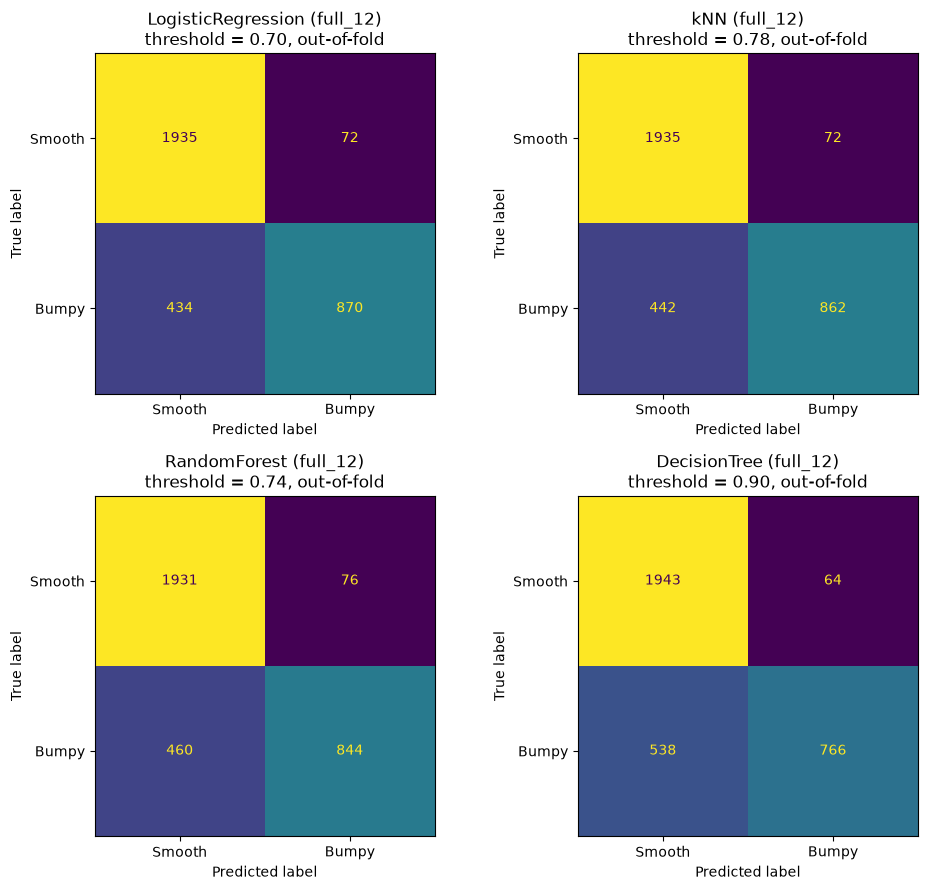

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Best configuration of each model family, ranked by the evaluation metric at its tuned threshold
best_per_model = (best_results_df
                  .sort_values(f"{evaluation_metric}_at_threshold", ascending=False)
                  .groupby("model", sort=False)
                  .head(1))

figure, subplot_grid = plt.subplots(2, 2, figsize=(10, 9))

for subplot, best_model in zip(subplot_grid.ravel(), best_per_model.itertuples()):

    train_features = train_df[model_features_data[best_model.feature_set]]

    # Each window predicted by a model trained on the other folds
    bumpy_probabilities = cross_val_predict(best_model.estimator, train_features, y_train,
                                            cv=cv_splits, method="predict_proba", n_jobs=-1)[:, 1]
    
    predicted_labels = (bumpy_probabilities >= best_model.best_threshold).astype(int)

    confusion = confusion_matrix(y_train, predicted_labels, labels=[0, 1])
    ConfusionMatrixDisplay(confusion, display_labels=["Smooth", "Bumpy"]).plot(
        ax=subplot, colorbar=False, values_format="d")
    subplot.set_title(f"{best_model.model} ({best_model.feature_set})\n"
                      f"threshold = {best_model.best_threshold:.2f}, out-of-fold")

plt.tight_layout()
plt.show()
